Selecting previously unselected package tesseract-ocr-kor.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-kor_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-kor (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-kor (1:4.00~git30-7274cfa-1.1) ...
이미지 파일 업로드


Saving 1.png to 1.png


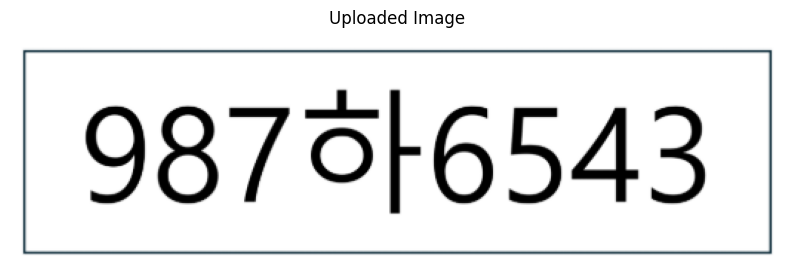


OCR 인식 결과
987하6543



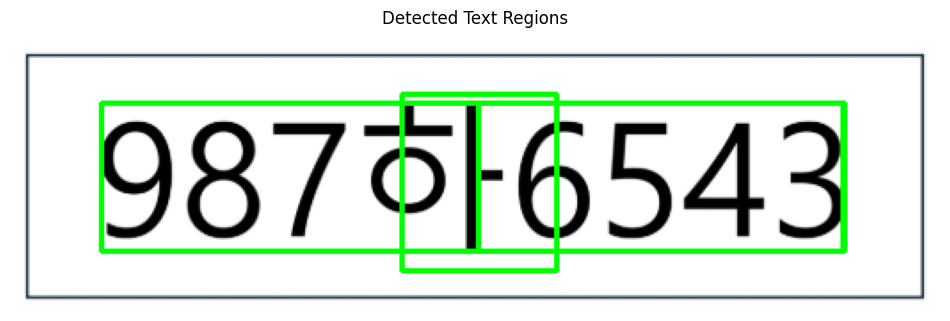

In [1]:
# ============================================================
# 이미지 OCR 텍스트 추출 (Google Colab)
# 업로드한 이미지 내 텍스트 인식 후 출력
# ============================================================

# OCR 엔진 설치
!apt-get -qq install tesseract-ocr tesseract-ocr-kor
!pip -q install pytesseract pillow opencv-python

import cv2
import numpy as np
import pytesseract
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

# ============================================================
# 1. 이미지 업로드
# ============================================================

print("="*60)
print("이미지 파일 업로드")
print("="*60)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ============================================================
# 2. 이미지 읽기
# ============================================================

img = cv2.imread(file_name)

# 원본 표시
plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# ============================================================
# 3. OCR 전처리
# ============================================================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 노이즈 제거
gray = cv2.GaussianBlur(gray, (3,3), 0)

# 이진화
_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# ============================================================
# 4. OCR 수행
# ============================================================

custom_config = r'--oem 3 --psm 6'

text = pytesseract.image_to_string(
    thresh,
    lang='kor+eng',
    config=custom_config
)

# ============================================================
# 5. 결과 출력
# ============================================================

print("\n" + "="*60)
print("OCR 인식 결과")
print("="*60)
print(text)

# ============================================================
# 6. OCR 위치 정보 출력 (선택)
# ============================================================

data = pytesseract.image_to_data(
    thresh,
    lang='kor+eng',
    config=custom_config,
    output_type=pytesseract.Output.DICT
)

result_img = img.copy()

for i in range(len(data['text'])):
    txt = data['text'][i].strip()
    conf = int(float(data['conf'][i]))

    if txt != "" and conf > 30:
        x = data['left'][i]
        y = data['top'][i]
        w = data['width'][i]
        h = data['height'][i]

        cv2.rectangle(
            result_img,
            (x, y),
            (x+w, y+h),
            (0,255,0),
            2
        )

plt.figure(figsize=(12,10))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Text Regions")
plt.show()